{'01': 276, '10': 251, '00': 237, '11': 260}


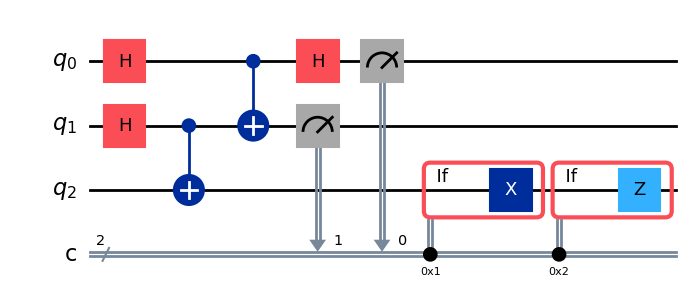

In [11]:
#Quantum Teleportation
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
qc = QuantumCircuit(3,2)
# Prepare state
qc.h(0)
# Bell pair
qc.h(1)
qc.cx(1,2)
# Teleportation protocol
qc.cx(0,1)
qc.h(0)
# Measurement
qc.measure(0,0)
qc.measure(1,1)
# Conditional corrections
'''qc.x(2).c_if(qc.cregs[0],1)
qc.z(2).c_if(qc.cregs[0],2)'''
with qc.if_test((qc.cregs[0], 1)):
    qc.x(2)
with qc.if_test((qc.cregs[0], 2)):
    qc.z(2)
sim = AerSimulator()
compiled = transpile(qc,sim)
result = sim.run(compiled,shots=1024).result()
counts = result.get_counts()
print(counts)
qc.draw('mpl')